In [30]:
#1) IMPORT NECESSARY LIBRARIES

import pandas as pd
import pmdarima as pm
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#2) LOAD THE DATA
data=pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Time series analysis/merged files/csv/apple_data.csv')

In [5]:
#3) DO SOME CLEANING IF NECESSARY

data = data.drop(columns=['Unnamed: 0'])

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d", errors="coerce")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

In [6]:
#4) CREATE BACKTESTING DATASET

data_bt = data.iloc[:-4]

START THE SET UP FOR THE PROPHET MODEL

In [7]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº of quarters to forecast
FREQ = "Q"            # trimestral frecuency
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df[REG_COLS] = df[REG_COLS].ffill()

In [8]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST - BACKTESTING DATASET

# ================== PREP ====================
df_bt = data_bt.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df_bt.columns:
        df_bt[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

SET UP THE ARIMA MODEL TO FORECAST THE REGRESSORS

In [9]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS
# ================== FUTURE SCENARIO ==================

revenue = data.set_index("ds")["revenue_musd"]
net_income = data.set_index("ds")["net_income_musd"]
total_assets = data.set_index("ds")["total_assets_musd"]
total_liabilities = data.set_index("ds")["total_liabilities_musd"]
total_equity = data.set_index("ds")["share_holder_equity_musd"]

metrics = {
    "revenue":revenue,
    "net_income": net_income,
    "total_assets": total_assets,
    "total_liabilities": total_liabilities,
    "total_equity": total_equity
    }

results = {}

for name, series in metrics.items():
    print(f"\nFitting model for {name}...")
    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results[name] = model
    print(f"Best order for {name}: {model.order}, seasonal: {model.seasonal_order}")

forecast_dic = {}

for name, model in results.items():
    fc = model.predict(n_periods=4)
    forecast_dic[name] = fc
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc)


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (1, 0, 0), seasonal: (0, 1, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for net_income: (1, 0, 0), seasonal: (0, 1, 1, 4)

Fitting model for total_assets...


...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (1, 1, 0), seasonal: (0, 1, 2, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 1), seasonal: (1, 0, 2, 4)

-revenue forecast for next 4 quarters:
2025-09-30    102265.836211
2025-12-31    131034.590647
2026-03-31    101702.006584
2026-06-30    100123.972555
Freq: QE-DEC, dtype: float64

-net_income forecast for next 4 quarters:
2025-09-30    20547.405237
2025-12-31    37314.084134
2026-03-31    26954.577559
2026-06-30    24835.499501
Freq: QE-DEC, dtype: float64

-total_assets forecast for next 4 quarters:
2025-09-30    348155.696054
2025-12-31    341449.410483
2026-03-31    327077.041836
2026-06-30    329875.393859
Freq: QE-DEC, dtype: float64

-total_liabilities forecast for next 4 quarters:
2025-09-30    303476.580534
2025-12-31    282253.819655
2026-03-31    267810.250795
2026-06-30    269281.258126
Freq: QE-DEC, dtype: float64

-total_equity forecast for next 4 quarters:
2025-09-30    64038.934627
2025-12-31    70677.351882
2026-03-31    71389.858476
2026-06-30    69198.950664
Freq: QE-DEC, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [10]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================

revenue_bt = data_bt.set_index("ds")["revenue_musd"]
net_income_bt = data_bt.set_index("ds")["net_income_musd"]
total_assets_bt = data_bt.set_index("ds")["total_assets_musd"]
total_liabilities_bt = data_bt.set_index("ds")["total_liabilities_musd"]
total_equity_bt = data_bt.set_index("ds")["share_holder_equity_musd"]

metrics_bt = {
    "revenue":revenue_bt,
    "net_income": net_income_bt,
    "total_assets": total_assets_bt,
    "total_liabilities": total_liabilities_bt,
    "total_equity": total_equity_bt
    }

results_bt = {}

for name, series in metrics_bt.items():
    print(f"\nFitting model for {name}...")
    model_bt = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results_bt[name] = model_bt
    print(f"Best order for {name}: {model_bt.order}, seasonal: {model_bt.seasonal_order}")

forecast_dic_bt = {}

for name, model in results_bt.items():
    fc_bt = model.predict(n_periods=4)
    forecast_dic_bt[name] = fc_bt
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc_bt)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (1, 0, 0), seasonal: (0, 1, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (0, 0, 2, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 1), seasonal: (1, 0, 1, 4)

-revenue forecast for next 4 quarters:
2024-09-30     93997.966801
2024-12-31    124414.175747
2025-03-31     95813.464317
2025-06-30     90981.825577
Freq: QE-DEC, dtype: float64

-net_income forecast for next 4 quarters:
2024-09-30    23457.126372
2024-12-31    35519.685258
2025-03-31    25572.677942
2025-06-30    22449.670064
Freq: QE-DEC, dtype: float64

-total_assets forecast for next 4 quarters:
2024-09-30    347075.888145
2024-12-31    351884.907517
2025-03-31    337076.770302
2025-06-30    331310.370510
Freq: QE-DEC, dtype: float64

-total_liabilities forecast for next 4 quarters:
2024-09-30    279553.073893
2024-12-31    277482.470013
2025-03-31    262888.677938
2025-06-30    263807.649378
Freq: QE-DEC, dtype: float64

-total_equity forecast for next 4 quarters:
2024-09-30    66147.956807
2024-12-31    72324.408393
2025-03-31    72967.763553
2025-06-30    70307.571800
Freq: QE-DEC, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [11]:
#7) Create future dataframe for Prophet
# ================== FUTURE SCENARIO ==================
# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/659787550.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [12]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,3.155715,9084.0,1620.0,43237.0,18926.0,24311.0,-3.23,0.15
1,2009-06-30,4.275764,9734.0,1828.0,48140.0,22252.0,25888.0,-3.98,0.16
2,2009-09-30,5.564229,12207.0,2532.0,47501.0,15861.0,31640.0,-3.13,0.12
3,2009-12-31,6.326139,15683.0,3378.0,53926.0,18158.0,35768.0,0.11,0.11
4,2010-03-31,7.054725,13499.0,3074.0,57057.0,17709.0,39348.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-06-30,204.937408,94036.0,23434.0,331495.0,265665.0,65830.0,1.99,4.33
66,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
67,2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
68,2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33


In [13]:
#7) Create future dataframe for Prophet - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================
# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/785312754.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [14]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA
forecast_dic = pd.DataFrame(forecast_dic)
forecast_dic = forecast_dic.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic = forecast_dic.reset_index()
forecast_dic = forecast_dic.rename(columns={"index": "ds"})
forecast_dic["ds"] = pd.to_datetime(forecast_dic["ds"])

In [15]:
forecast_dic

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2025-09-30,102265.836211,20547.405237,348155.696054,303476.580534,64038.934627
1,2025-12-31,131034.590647,37314.084134,341449.410483,282253.819655,70677.351882
2,2026-03-31,101702.006584,26954.577559,327077.041836,267810.250795,71389.858476
3,2026-06-30,100123.972555,24835.499501,329875.393859,269281.258126,69198.950664


In [16]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA - BACKTESTING DATA

forecast_dic_bt = pd.DataFrame(forecast_dic_bt)
forecast_dic_bt = forecast_dic_bt.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic_bt = forecast_dic_bt.reset_index()
forecast_dic_bt = forecast_dic_bt.rename(columns={"index": "ds"})
forecast_dic_bt["ds"] = pd.to_datetime(forecast_dic_bt["ds"])

In [17]:
forecast_dic_bt

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2024-09-30,93997.966801,23457.126372,347075.888145,279553.073893,66147.956807
1,2024-12-31,124414.175747,35519.685258,351884.907517,277482.470013,72324.408393
2,2025-03-31,95813.464317,25572.677942,337076.770302,262888.677938,72967.763553
3,2025-06-30,90981.825577,22449.670064,331310.370510,263807.649378,70307.571800


In [18]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET
future_full = pd.concat([future_full, forecast_dic], ignore_index=True)

future_full = future_full.sort_values(by="ds").reset_index(drop=True)
future_full = future_full.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full = future_full.drop_duplicates(subset=["ds"], keep="first")
future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/1001450928.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-03-31,170.257339,90753.000000,23636.000000,337411.000000,263217.000000,74194.000000,2.90,5.33
61,2024-06-30,209.401932,85777.000000,21448.000000,331612.000000,264904.000000,66708.000000,3.04,5.33
62,2024-09-30,231.920639,94930.000000,14736.000000,364980.000000,308030.000000,56950.000000,2.72,4.83
63,2024-12-31,249.534180,124300.000000,36330.000000,344085.000000,277327.000000,66758.000000,2.53,4.33
64,2025-03-31,221.587616,95359.000000,24780.000000,331233.000000,264437.000000,66796.000000,1.99,4.33
65,2025-06-30,204.937408,94036.000000,23434.000000,331495.000000,265665.000000,65830.000000,1.99,4.33
67,2025-09-30,NaN,102265.836211,20547.405237,348155.696054,303476.580534,64038.934627,1.99,4.33
69,2025-12-31,NaN,131034.590647,37314.084134,341449.410483,282253.819655,70677.351882,1.99,4.33
71,2026-03-31,NaN,101702.006584,26954.577559,327077.041836,267810.250795,71389.858476,1.99,4.33
73,2026-06-30,NaN,100123.972555,24835.499501,329875.393859,269281.258126,69198.950664,1.99,4.33


In [19]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET - BACKTESTING DATA

future_full_bt = pd.concat([future_full_bt, forecast_dic_bt], ignore_index=True)

future_full_bt = future_full_bt.sort_values(by="ds").reset_index(drop=True)
future_full_bt = future_full_bt.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full_bt = future_full_bt.drop_duplicates(subset=["ds"], keep="first")
future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full_bt[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/79476634.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-03-31,170.257339,90753.000000,23636.000000,337411.000000,263217.000000,74194.000000,2.90,5.33
61,2024-06-30,209.401932,85777.000000,21448.000000,331612.000000,264904.000000,66708.000000,3.04,5.33
63,2024-09-30,NaN,93997.966801,23457.126372,347075.888145,279553.073893,66147.956807,3.04,5.33
65,2024-12-31,NaN,124414.175747,35519.685258,351884.907517,277482.470013,72324.408393,3.04,5.33
67,2025-03-31,NaN,95813.464317,25572.677942,337076.770302,262888.677938,72967.763553,3.04,5.33
69,2025-06-30,NaN,90981.825577,22449.670064,331310.370510,263807.649378,70307.571800,3.04,5.33


In [20]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


13:28:06 - cmdstanpy - INFO - Chain [1] start processing
13:28:07 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  165.117489  148.707084  181.135468  169.549286
59 2023-12-31  182.896609  166.988505  197.643323  190.913651
60 2024-03-31  186.294950  170.622365  201.269269  170.257339
61 2024-06-30  201.874080  185.636705  218.710662  209.401932
62 2024-09-30  201.502066  185.870211  217.298957  231.920639
63 2024-12-31  233.711827  218.013261  249.508891  249.534180
64 2025-03-31  208.411526  192.359260  223.480497  221.587616
65 2025-06-30  213.550147  196.836063  229.347630  204.937408
66 2025-09-30  215.588621  199.715745  231.610556         NaN
67 2025-12-31  241.021591  224.519214  256.062917         NaN
68 2026-03-31  227.537287  212.234492  244.072133         NaN
69 2026-06-30  228.107454  211.137477  243.049182         NaN


In [21]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET - BACKTESTING DATA

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

13:28:07 - cmdstanpy - INFO - Chain [1] start processing
13:28:07 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30  134.283849  121.934735  147.516647  136.052307
55 2022-12-31  154.350872  140.139035  166.374012  128.123062
56 2023-03-31  165.701649  153.695161  178.042455  162.854996
57 2023-06-30  161.817992  150.198582  175.933132  191.829453
58 2023-09-30  165.703415  153.147579  178.251314  169.549286
59 2023-12-31  190.003163  176.581880  202.542006  190.913651
60 2024-03-31  178.582002  164.917968  190.721151  170.257339
61 2024-06-30  191.783240  179.124073  204.571281  209.401932
62 2024-09-30  199.119303  186.091617  210.927923         NaN
63 2024-12-31  238.239601  226.103528  251.288039         NaN
64 2025-03-31  209.078585  196.427071  221.743672         NaN
65 2025-06-30  202.511263  190.051753  215.361684         NaN


In [22]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 9.528804074132987
RMSE: 149.66069270973742
R²: 0.970164253574607
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  165.117489  148.707084  181.135468  169.549286      False
59 2023-12-31  182.896609  166.988505  197.643323  190.913651      False
60 2024-03-31  186.294950  170.622365  201.269269  170.257339      False
61 2024-06-30  201.874080  185.636705  218.710662  209.401932      False
62 2024-09-30  201.502066  185.870211  217.298957  231.920639      False
63 2024-12-31  233.711827  218.013261  249.508891  249.534180      False
64 2025-03-31  208.411526  192.359260  223.480497  221.587616      False
65 2025-06-30  213.550147  196.836063  229.347630  204.937408      False
66 2025-09-30  215.588621  199.715745  231.610556         NaN       True
67 2025-12-31  241.021591  224.519214  256.062917         NaN       True
68 2026-03-31  227.537287  212.234492  244.072133         NaN       True
69 2026-06-30  228.107454  211.137477  243.049182     

In [23]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS - BACKTESTING DATA

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 7.580405137905713
RMSE: 97.6269785719389
R²: 0.9730049477120175
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30  134.283849  121.934735  147.516647  136.052307      False
55 2022-12-31  154.350872  140.139035  166.374012  128.123062      False
56 2023-03-31  165.701649  153.695161  178.042455  162.854996      False
57 2023-06-30  161.817992  150.198582  175.933132  191.829453      False
58 2023-09-30  165.703415  153.147579  178.251314  169.549286      False
59 2023-12-31  190.003163  176.581880  202.542006  190.913651      False
60 2024-03-31  178.582002  164.917968  190.721151  170.257339      False
61 2024-06-30  191.783240  179.124073  204.571281  209.401932      False
62 2024-09-30  199.119303  186.091617  210.927923         NaN       True
63 2024-12-31  238.239601  226.103528  251.288039         NaN       True
64 2025-03-31  209.078585  196.427071  221.743672         NaN       True
65 2025-06-30  202.511263  190.051753  215.361684      

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/433884081.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


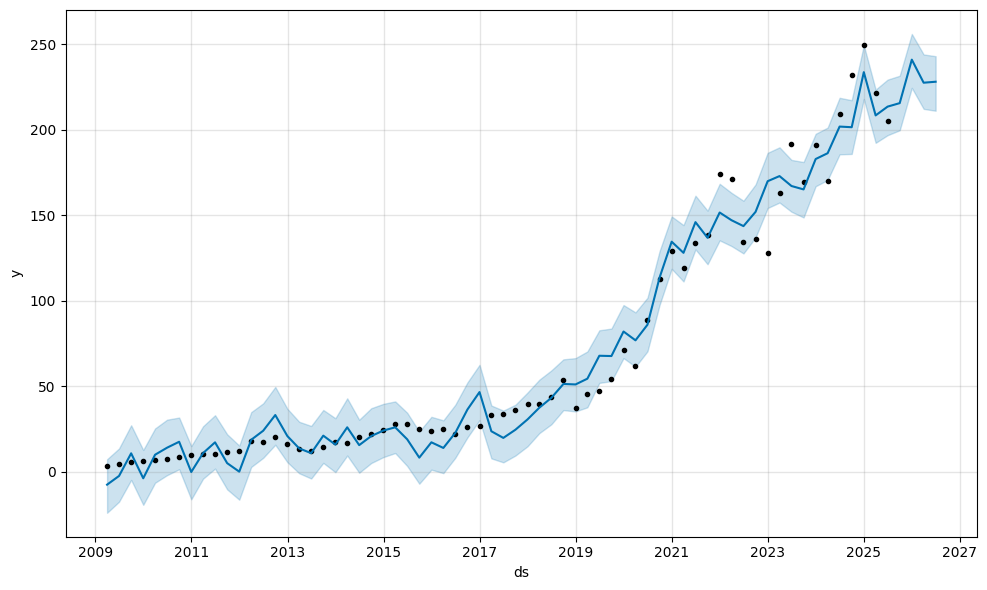

In [24]:
#12) PLOT THE RESULTS

figl = m.plot(forecast)
figl.show()

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_22440/3458915387.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


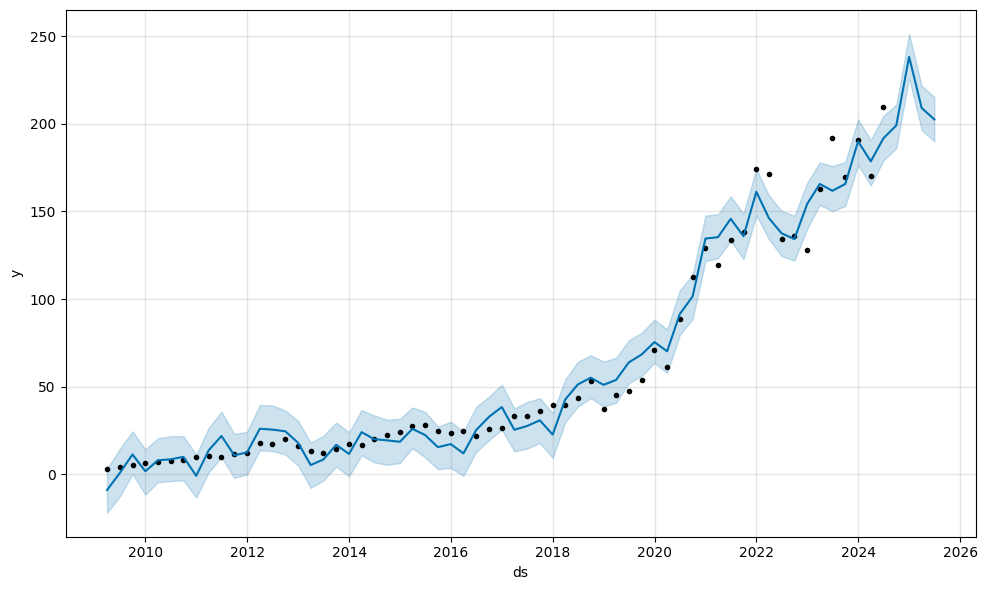

In [25]:
#12) PLOT THE RESULTS - BACKTESTING DATA

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()


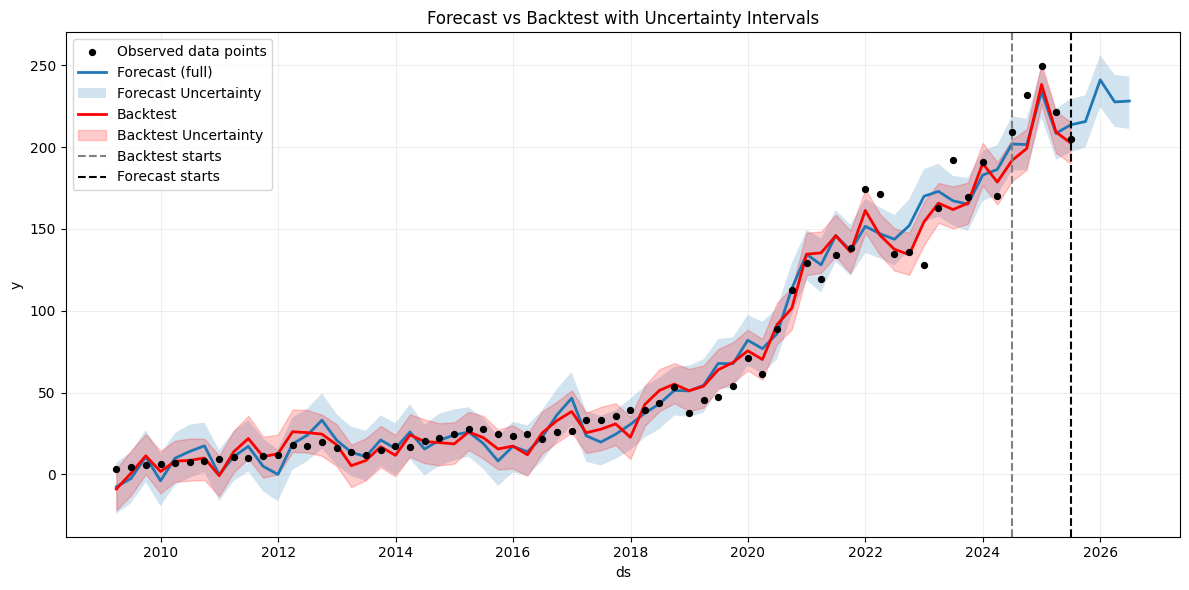

In [26]:
#13) PLOT THE FORECAST VS BACKTEST WITH UNCERTAINTY INTERVALS

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'].eq(False), 'ds'].max()   # ~2024-06-30
full_split = results.loc[results['is_future'].eq(False), 'ds'].max()         # ~2025-06-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

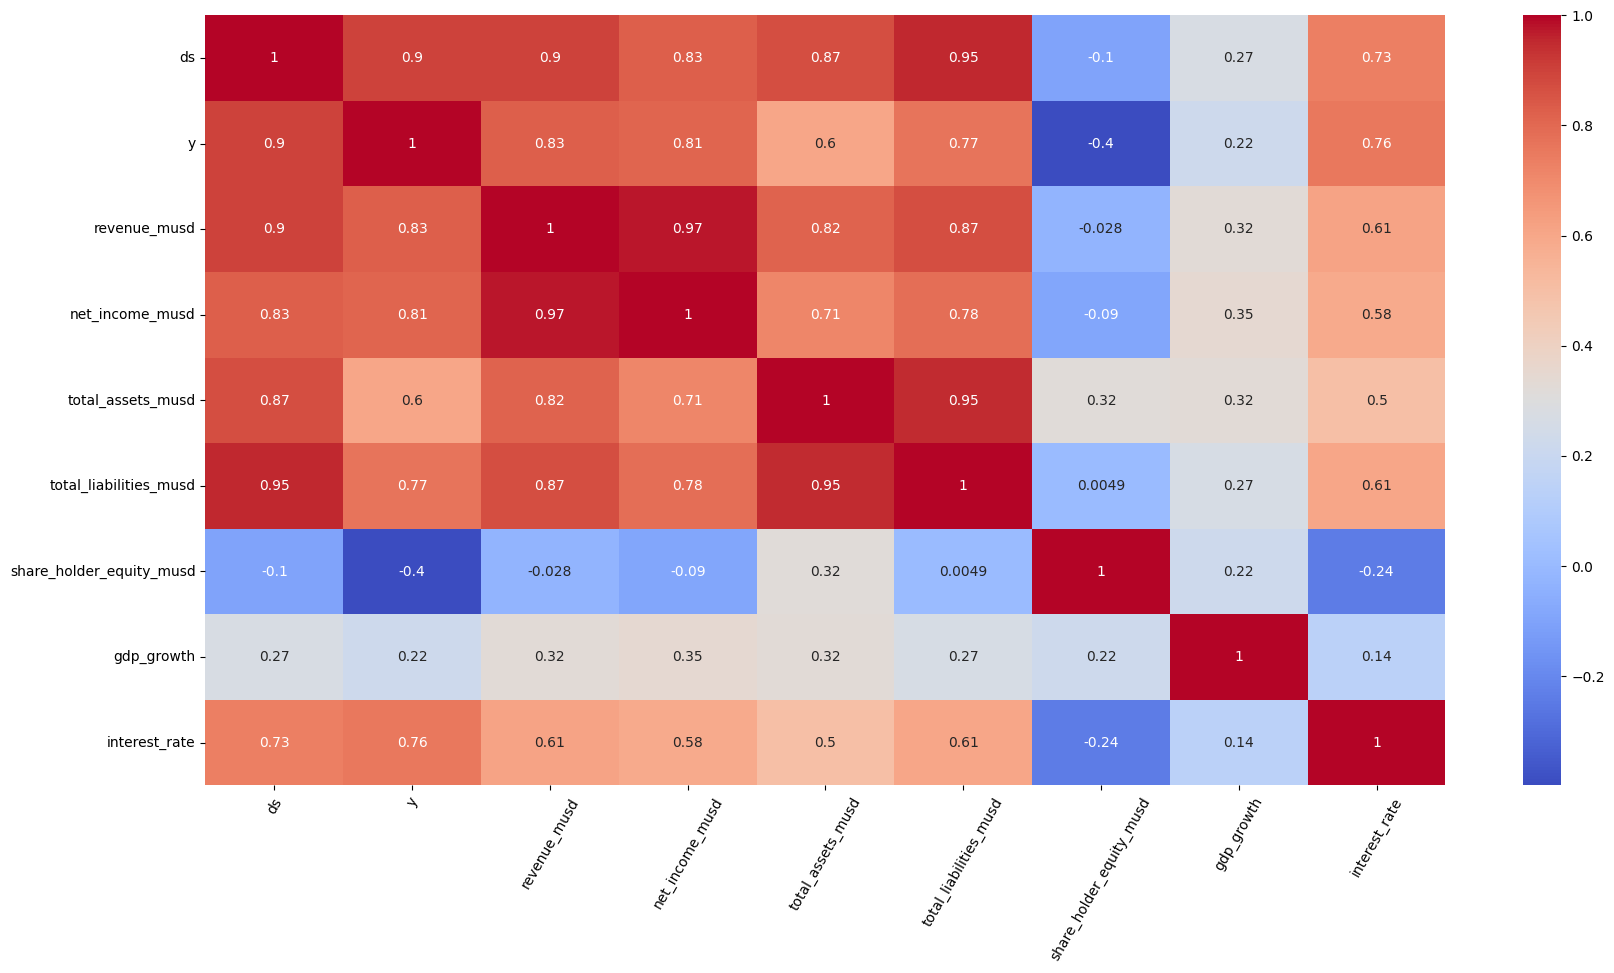

In [43]:
# correlation map

carr = data.corr()
plt.figure(figsize=(20,10))
sns.heatmap(carr, annot=True, cmap="coolwarm")
plt.xticks(rotation=60)
plt.show()
